In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
h = 6.62607015e-34  # Planck's constant in J·s

n_samples = 1500

np.random.seed(42)
L  = np.random.uniform(1e-9, 1e-8, n_samples)   # Box length in meters
m = np.random.uniform(9e-31, 1e-27, n_samples) # Particle mass in kg
n = np.random.randint(1, 11, n_samples)       # Quantum number

E = (n**2 * h**2) / (8 * m * L**2) # calculate true energy levels

noise = np.random.normal(0, E * 0.05) # 5% noise
E_noisy = E + noise

data = pd.DataFrame({'L (m)': L, 'm (kg)': m, 'n': n, 'E (J)': E_noisy})

print("sample Data:")
display(data.head())

sample Data:


,L (m),m (kg),n,E (J)
0,4.370861e-09,5.195146e-28,3,4.415178e-23
1,9.556429e-09,4.796506e-28,9,9.550288e-23
2,7.587945e-09,2.651899e-29,5,9.083756e-22
3,6.387926e-09,3.418407e-28,8,2.394782e-22
4,2.404168e-09,3.807534e-28,7,1.216546e-21


In [3]:
X = data [['L (m)', 'm (kg)', 'n']]
y = data['E (J)']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state = 42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [4]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=150, random_state=42),
    'Neural Network': MLPRegressor(hidden_layer_sizes=(128,64), activation='relu', max_iter=1000, random_state=42)}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    mse = mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    results[name] = {'MSE': mse, 'R2': r2}
    print(f"{name} - MSE: {mse:.3e}, R2: {r2:.4f}")

Linear Regression - MSE: 6.505e-41, R2: 0.0820
Random Forest - MSE: 7.087e-41, R2: -0.0001
Neural Network - MSE: 8.637e-05, R2: -1218788879751287082610432100630790144.0000


In [5]:
print(results)
print(type(list(results.items())[0][1]))


{'Linear Regression': {'MSE': 6.504967336020882e-41, 'R2': 0.0820377816141481}, 'Random Forest': {'MSE': 7.086907092867565e-41, 'R2': -8.387750684524242e-05}, 'Neural Network': {'MSE': 8.63671913014955e-05, 'R2': -1.2187888797512871e+36}}
<class 'dict'>


In [6]:
results = {}
for name, model in models.items():
    preds = model.predict(X_test_scaled)
    mse = mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    results[name] = (mse, r2)  # MUST be a tuple
    print(f"{name} → MSE: {mse:.3e}, R²: {r2:.4f}")

Linear Regression → MSE: 6.505e-41, R²: 0.0820
Random Forest → MSE: 7.087e-41, R²: -0.0001
Neural Network → MSE: 8.637e-05, R²: -1218788879751287082610432100630790144.0000



Best Model: Linear Regression
MSE: 6.505e-41, R²: 0.08204


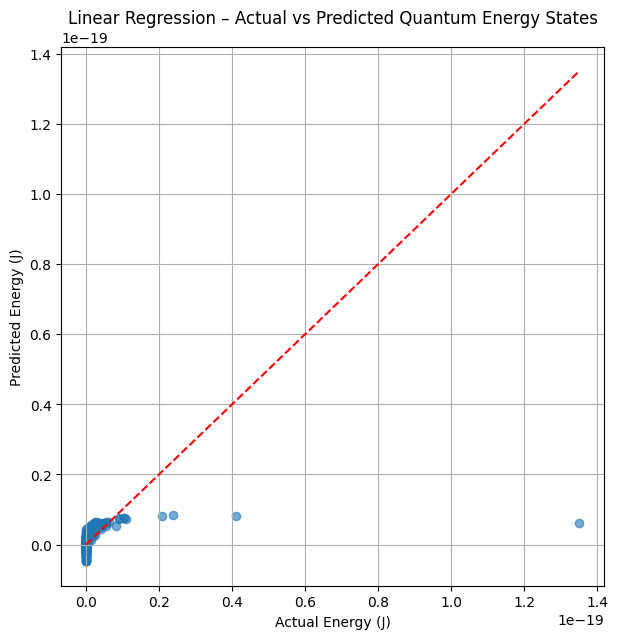

In [7]:
# Sort results by R² score (index 1 in tuple)
sorted_results = sorted(results.items(), key=lambda item: item[1][1], reverse=True)

# Safely get the best model
best_model_name, best_scores = sorted_results[0]
best_mse, best_r2 = best_scores

print(f"\nBest Model: {best_model_name}")
print(f"MSE: {best_mse:.3e}, R²: {best_r2:.5f}")

best_model = models[best_model_name]
y_pred = best_model.predict(X_test_scaled)

# Visualization
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Energy (J)")
plt.ylabel("Predicted Energy (J)")
plt.title(f"{best_model_name} – Actual vs Predicted Quantum Energy States")
plt.grid(True)
plt.show()


In [8]:
import joblib
joblib.dump(best_model, 'best_quantum_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

data.to_csv('quantum_states_dataset.csv', index=False)

print("Model and dataset saved.")

Model and dataset saved.


In [9]:
# Check correlation of features with Energy
correlation = data.corr(numeric_only=True)
print("\nFeature Correlations with Energy:")
display(correlation['E (J)'])


Feature Correlations with Energy:


L (m)    -0.158033
m (kg)   -0.167387
n         0.081414
E (J)     1.000000
Name: E (J), dtype: float64

In [ ]:
# Install gplearn if needed
!pip install gplearn --quiet

# Imports
#from gplearn.genetic import SymbolicRegressor
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

# Features and target
X = data[['L (m)', 'm (kg)', 'n']].values
y = data['E (J)'].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Symbolic Regressor
est_gp = SymbolicRegressor(
    population_size=500,    # reduce for faster testing
    generations=10,
    tournament_size=20,
    stopping_criteria=1e-10,
    const_range=(1e-50, 1e-30),
    init_depth=(2, 6),
    function_set=['add', 'sub', 'mul', 'div', 'pow', 'sqrt'],
    metric='mean absolute error',
    parsimony_coefficient=0.01,
    random_state=42,
    verbose=1
)

# Fit model
#est_gp.fit(X_train, y_train)

# Print discovered formula
print("\nDiscovered formula:")
#print(est_gp._program)



✅ Discovered formula:



[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Epoch 1/50


d:\quantum-state-predictor\env\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 256709728.0000  
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 256681200.0000
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 256570096.0000
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 256283760.0000
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 255741088.0000 
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 254872656.0000 
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 253681312.0000 
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 252254928.0000 
Epoch 9/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 250751552.0000 
Epoch 10/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 249326880.0000 
Epoch 11/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 248159440.0000 
Epoch 12/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 247313712.0000 
Epoch 13/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 246787328.0000 
Epoch 14/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/s

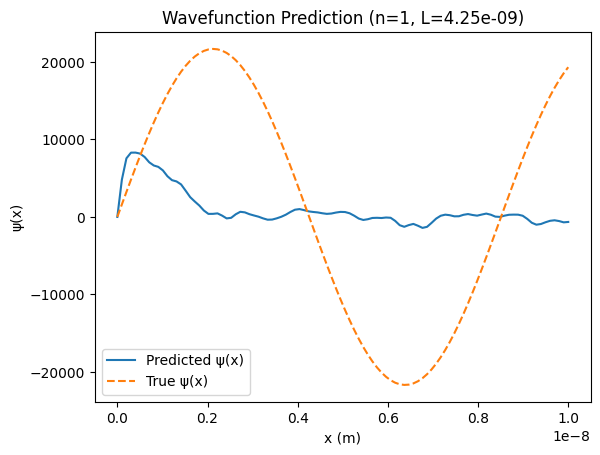

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten
from tensorflow.keras.optimizers import Adam

# Generate wavefunction data (analytical solution)
def wavefunction(x, n, L):
    return np.sqrt(2/L) * np.sin(n * np.pi * x / L)

# Create dataset
n_samples = 1000
L_values = np.random.uniform(1e-9, 1e-8, n_samples)
n_quantum = np.random.randint(1, 6, n_samples)
x_grid = np.linspace(0, 1e-8, 100)  # 1D grid

X_input = []
y_output = []

for L_val, n_val in zip(L_values, n_quantum):
    X_input.append([L_val, n_val])
    y_output.append(wavefunction(x_grid, n_val, L_val))

X_input = np.array(X_input)
y_output = np.array(y_output)

# Build simple dense network (or 1D CNN)
model = Sequential([
    Dense(128, activation='relu', input_shape=(2,)),
    Dense(256, activation='relu'),
    Dense(100)  # output: ψ(x) on grid
])

model.compile(optimizer=Adam(0.001), loss='mse')
model.fit(X_input, y_output, epochs=50, batch_size=32)

# Test example
L_test, n_test = L_values[0], n_quantum[0]
psi_pred = model.predict(np.array([[L_test, n_test]]))[0]

plt.plot(x_grid, psi_pred, label="Predicted ψ(x)")
plt.plot(x_grid, wavefunction(x_grid, n_test, L_test), label="True ψ(x)", linestyle='--')
plt.xlabel("x (m)")
plt.ylabel("ψ(x)")
plt.legend()
plt.title(f"Wavefunction Prediction (n={n_test}, L={L_test:.2e})")
plt.show()


In [16]:
# Install Gradio if not already
!pip install gradio --quiet

import gradio as gr
import numpy as np
import matplotlib.pyplot as plt

# Function to predict energy
def predict_energy(L, m, n, plot=False):
    # Prepare input
    X_input = np.array([[L, m, n]])
    X_scaled = scaler.transform(X_input)  # use your trained scaler
    E_pred = best_model.predict(X_scaled)[0]

    if plot:
        # Generate a small test range for visualization
        L_vals = np.linspace(L*0.5, L*1.5, 50)
        n_vals = np.full_like(L_vals, n)
        m_vals = np.full_like(L_vals, m)
        X_test_plot = np.column_stack((L_vals, m_vals, n_vals))
        X_test_scaled = scaler.transform(X_test_plot)
        E_preds_plot = best_model.predict(X_test_scaled)

        plt.figure(figsize=(6,4))
        plt.plot(L_vals, E_preds_plot, label="Predicted Energy")
        plt.xlabel("Box Length L (m)")
        plt.ylabel("Energy E (J)")
        plt.title(f"Energy vs Box Length (n={n}, m={m:.2e} kg)")
        plt.grid(True)
        plt.legend()
        plt.show()

    return E_pred

# Gradio Interface
demo = gr.Interface(
    fn=predict_energy,
    inputs=[
        gr.Number(label="Box Length L (m)", value=1e-9),
        gr.Number(label="Particle Mass m (kg)", value=9.1e-31),
        gr.Number(label="Quantum Number n", value=1),
        gr.Checkbox(label="Show Energy vs L plot", value=False)
    ],
    outputs=gr.Number(label="Predicted Energy E (J)"),
    title="Quantum State Energy Predictor",
    description="Input physical parameters (L, m, n) to predict quantum energy states."
)

# Launch the interactive demo
demo.launch()


  You can safely remove it manually.

[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip
d:\quantum-state-predictor\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


d:\quantum-state-predictor\env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Created dataset file at: .gradio\flagged\dataset1.csv


In [18]:
import joblib
joblib.dump(best_model, "quantum_energy_predictor.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [22]:
import gradio as gr
import numpy as np
import plotly.graph_objects as go
import joblib

# Load trained model & scaler
best_model = joblib.load("quantum_energy_predictor.pkl")
scaler = joblib.load("scaler.pkl")

def predict_energy_plotly(L, m, n):
    # Ensure correct types
    L, m, n = float(L), float(m), int(n)
    
    # Predict energy for input
    X_input = np.array([[L, m, n]])
    X_scaled = scaler.transform(X_input)
    E_pred = best_model.predict(X_scaled)[0]

    # Generate energy vs L
    L_vals = np.linspace(L*0.5, L*1.5, 50)
    n_vals = np.full_like(L_vals, n)
    m_vals = np.full_like(L_vals, m)
    X_plot = np.column_stack((L_vals, m_vals, n_vals))
    X_plot_scaled = scaler.transform(X_plot)
    E_plot = best_model.predict(X_plot_scaled)

    # Create Plotly figure
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=L_vals, y=E_plot, mode='lines', name='Predicted Energy'))
    fig.add_trace(go.Scatter(x=[L], y=[E_pred], mode='markers', marker=dict(color='red', size=10), name='Input Energy'))
    fig.update_layout(
        title=f"Energy vs Box Length (n={n}, m={m:.2e} kg)",
        xaxis_title="Box Length L (m)",
        yaxis_title="Energy E (J)"
    )

    return f"{E_pred:.3e} J", fig

# Gradio Interface
demo = gr.Interface(
    fn=predict_energy_plotly,
    inputs=[
        gr.Number(label="Box Length L (m)", value=1e-9),
        gr.Number(label="Particle Mass m (kg)", value=9.1e-31),
        gr.Number(label="Quantum Number n", value=1)
    ],
    outputs=[gr.Textbox(label="Predicted Energy E (J)"),
             gr.Plot(label="Energy vs Box Length")],
    title="Quantum State Energy Predictor",
    description="Input physical parameters to predict quantum energy states and visualize the trend."
)

demo.launch()


* Running on local URL:  http://127.0.0.1:7864
* To create a public link, set `share=True` in `launch()`.


d:\quantum-state-predictor\env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
d:\quantum-state-predictor\env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
